In [2]:
pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 1.3 MB/s eta 0:00:000m eta -:--:--
Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn import metrics

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

print("🚀 SMS Spam Detection Project Starting...")
print("=" * 60)

# Load the dataset
df = pd.read_csv('./spam.csv', encoding='latin-1')

# Clean the dataset - keep only relevant columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("✅ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")

🚀 SMS Spam Detection Project Starting...
✅ Dataset loaded successfully!
Dataset shape: (5572, 2)

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


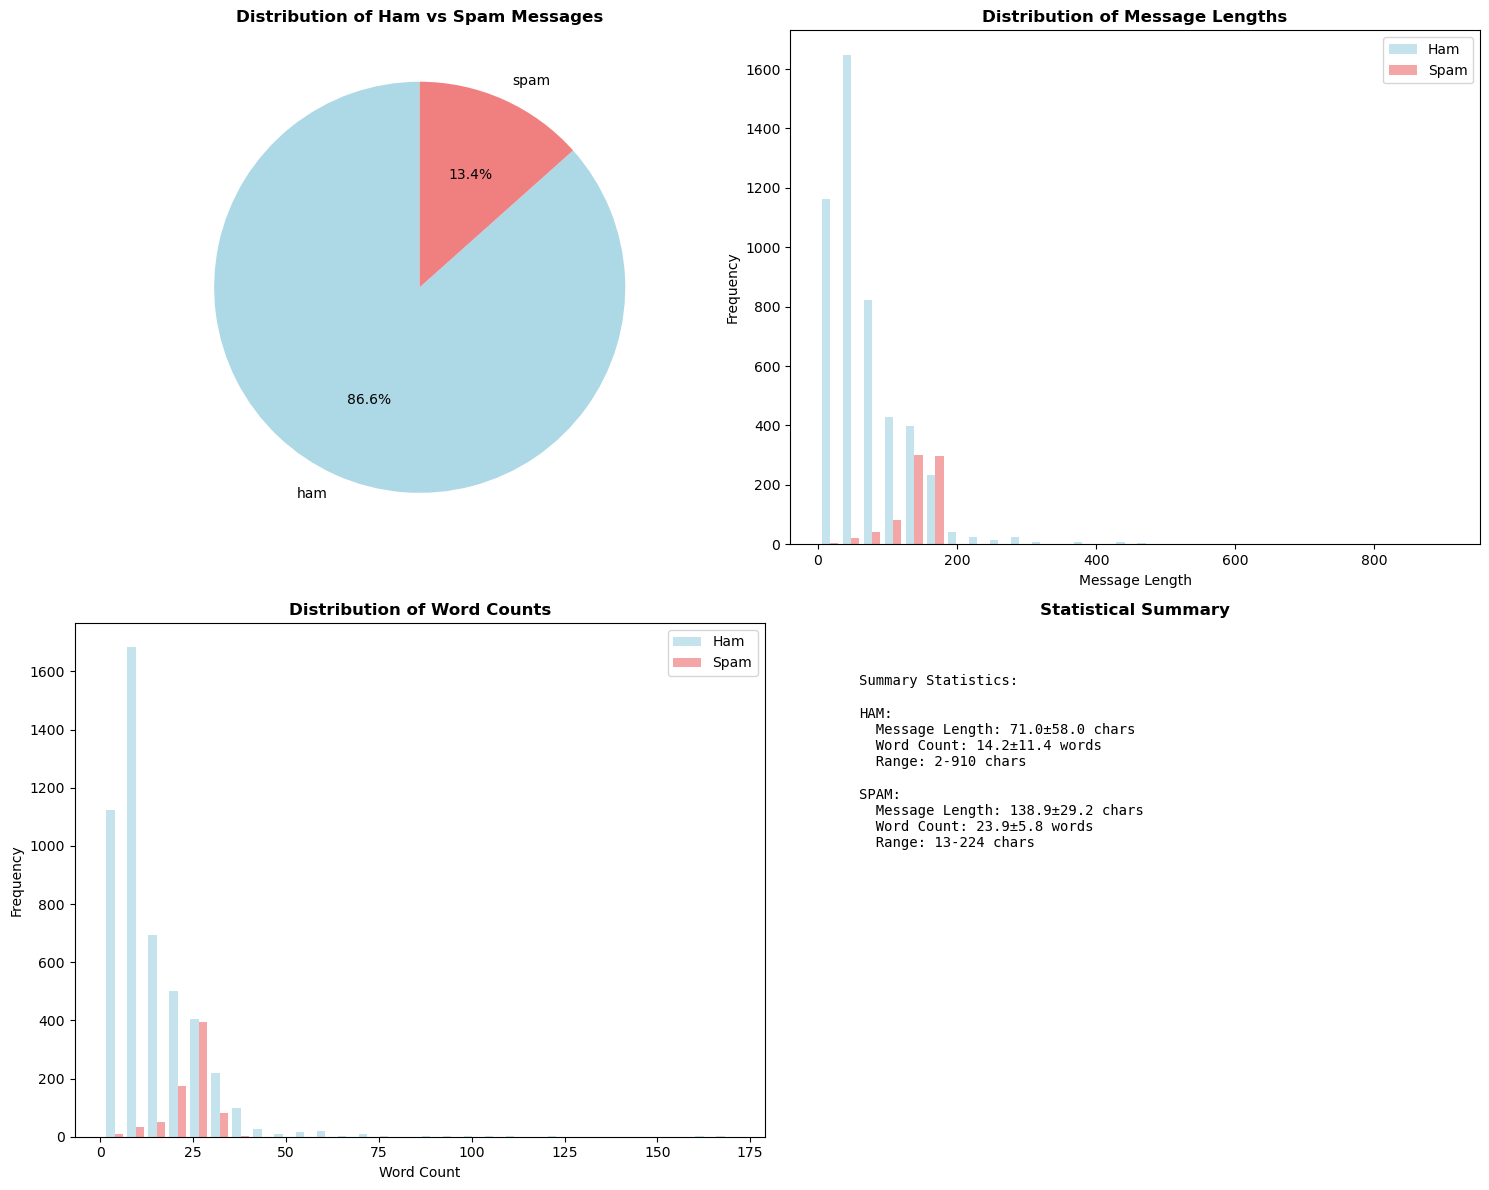


DATA ANALYSIS SUMMARY
Total messages: 5572
Ham messages: 4825 (86.59%)
Spam messages: 747 (13.41%)
Average message length - Ham: 71.02, Spam: 138.87
Average word count - Ham: 14.20, Spam: 23.85


In [13]:
# Create subplots for EDA
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2.1 Class Distribution
class_dist = df['label'].value_counts()
axes[0,0].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
axes[0,0].set_title('Distribution of Ham vs Spam Messages', fontweight='bold')

# 2.2 Message Length Analysis
df['message_length'] = df['message'].apply(len)
ham_lengths = df[df['label'] == 'ham']['message_length']
spam_lengths = df[df['label'] == 'spam']['message_length']

axes[0,1].hist([ham_lengths, spam_lengths], bins=30, label=['Ham', 'Spam'], alpha=0.7, color=['lightblue', 'lightcoral'])
axes[0,1].set_xlabel('Message Length')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Message Lengths', fontweight='bold')
axes[0,1].legend()

# 2.3 Word Count Analysis
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
ham_words = df[df['label'] == 'ham']['word_count']
spam_words = df[df['label'] == 'spam']['word_count']

axes[1,0].hist([ham_words, spam_words], bins=30, label=['Ham', 'Spam'], alpha=0.7, color=['lightblue', 'lightcoral'])
axes[1,0].set_xlabel('Word Count')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Word Counts', fontweight='bold')
axes[1,0].legend()

# 2.4 Fixed Summary Statistics
axes[1,1].axis('off')

# Calculate statistics properly
stats_data = []
for label in ['ham', 'spam']:
    subset = df[df['label'] == label]
    stats_data.append({
        'Label': label,
        'Msg Len Mean': subset['message_length'].mean(),
        'Msg Len Std': subset['message_length'].std(),
        'Msg Len Min': subset['message_length'].min(),
        'Msg Len Max': subset['message_length'].max(),
        'Word Count Mean': subset['word_count'].mean(),
        'Word Count Std': subset['word_count'].std(),
        'Word Count Min': subset['word_count'].min(),
        'Word Count Max': subset['word_count'].max()
    })

stats_text = "Summary Statistics:\n\n"
for stat in stats_data:
    stats_text += f"{stat['Label'].upper()}:\n"
    stats_text += f"  Message Length: {stat['Msg Len Mean']:.1f}±{stat['Msg Len Std']:.1f} chars\n"
    stats_text += f"  Word Count: {stat['Word Count Mean']:.1f}±{stat['Word Count Std']:.1f} words\n"
    stats_text += f"  Range: {stat['Msg Len Min']}-{stat['Msg Len Max']} chars\n\n"

axes[1,1].text(0.1, 0.9, stats_text, fontsize=10, family='monospace', verticalalignment='top')
axes[1,1].set_title('Statistical Summary', fontweight='bold')

plt.tight_layout()
plt.show()

# Print additional statistics
print("\n" + "="*50)
print("DATA ANALYSIS SUMMARY")
print("="*50)
print(f"Total messages: {len(df)}")
print(f"Ham messages: {len(df[df['label']=='ham'])} ({len(df[df['label']=='ham'])/len(df)*100:.2f}%)")
print(f"Spam messages: {len(df[df['label']=='spam'])} ({len(df[df['label']=='spam'])/len(df)*100:.2f}%)")
print(f"Average message length - Ham: {ham_lengths.mean():.2f}, Spam: {spam_lengths.mean():.2f}")
print(f"Average word count - Ham: {ham_words.mean():.2f}, Spam: {spam_words.mean():.2f}")

In [14]:
print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)

# Convert labels to binary
df['class'] = df['label'].map({'ham': 0, 'spam': 1})
Y = df['class'].values

# Split the data
df_train, df_test, Ytrain, Ytest = train_test_split(
    df['message'], Y, test_size=0.2, random_state=42, stratify=Y
)

print(f"Training set size: {len(df_train)}")
print(f"Testing set size: {len(df_test)}")
print(f"Training set - Ham: {(Ytrain == 0).sum()}, Spam: {(Ytrain == 1).sum()}")
print(f"Testing set - Ham: {(Ytest == 0).sum()}, Spam: {(Ytest == 1).sum()}")

# Tokenization
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 160

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token='<OOV>',
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)
tokenizer.fit_on_texts(df_train)

# Convert texts to sequences
sequences_train = tokenizer.texts_to_sequences(df_train)
sequences_test = tokenizer.texts_to_sequences(df_test)

# Pad sequences
X_train = pad_sequences(sequences_train, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test = pad_sequences(sequences_test, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"\nVocabulary size: {len(tokenizer.word_index)}")
print(f"Shape of training data: {X_train.shape}")
print(f"Shape of testing data: {X_test.shape}")


DATA PREPROCESSING
Training set size: 4457
Testing set size: 1115
Training set - Ham: 3859, Spam: 598
Testing set - Ham: 966, Spam: 149

Vocabulary size: 7919
Shape of training data: (4457, 160)
Shape of testing data: (1115, 160)


In [15]:
def create_spam_detection_model(vocab_size, sequence_length, embedding_dim=100):
    """
    Create LSTM model for spam detection
    """
    # Input layer
    input_layer = Input(shape=(sequence_length,))
    
    # Embedding layer
    embedding = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=sequence_length,
        mask_zero=True
    )(input_layer)
    
    # LSTM layer
    lstm_layer = LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(embedding)
    
    # Global max pooling
    pooling_layer = GlobalMaxPooling1D()(lstm_layer)
    
    # Dense layers
    dense_layer = Dense(32, activation='relu')(pooling_layer)
    dense_layer = Dropout(0.3)(dense_layer)
    
    # Output layer
    output_layer = Dense(1, activation='sigmoid')(dense_layer)
    
    # Create model
    model = Model(inputs=input_layer, outputs=output_layer)
    
    return model

print("\n" + "="*50)
print("MODEL ARCHITECTURE")
print("="*50)

model = create_spam_detection_model(
    vocab_size=MAX_VOCAB_SIZE,
    sequence_length=MAX_SEQUENCE_LENGTH,
    embedding_dim=128
)

# Display model summary
model.summary()

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)


MODEL ARCHITECTURE


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 160, 128)  │  2,560,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 160)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 160, 64)   │     49,408 │ embedding_1[0][0… │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ lstm_1[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 2,611,521 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

print("\n" + "="*50)
print("MODEL TRAINING")
print("="*50)

# Train the model
history = model.fit(
    x=X_train,
    y=Ytrain,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


MODEL TRAINING
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.9178 - loss: 0.2903 - val_accuracy: 0.9776 - val_loss: 0.0835 - learning_rate: 0.0010
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.9916 - loss: 0.0399 - val_accuracy: 0.9843 - val_loss: 0.0725 - learning_rate: 0.0010
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.9978 - loss: 0.0125 - val_accuracy: 0.9854 - val_loss: 0.0700 - learning_rate: 0.0010
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9994 - loss: 0.0046 - val_accuracy: 0.9854 - val_loss: 0.0689 - learning_rate: 0.0010
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9854 - val_loss: 0.0795 - learning_rate: 0.0010
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 1.0000 - loss: 8.5287e-04 - val_accuracy: 0.9843 - val_loss: 0.0913 - learning_rate: 0.0010
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accura

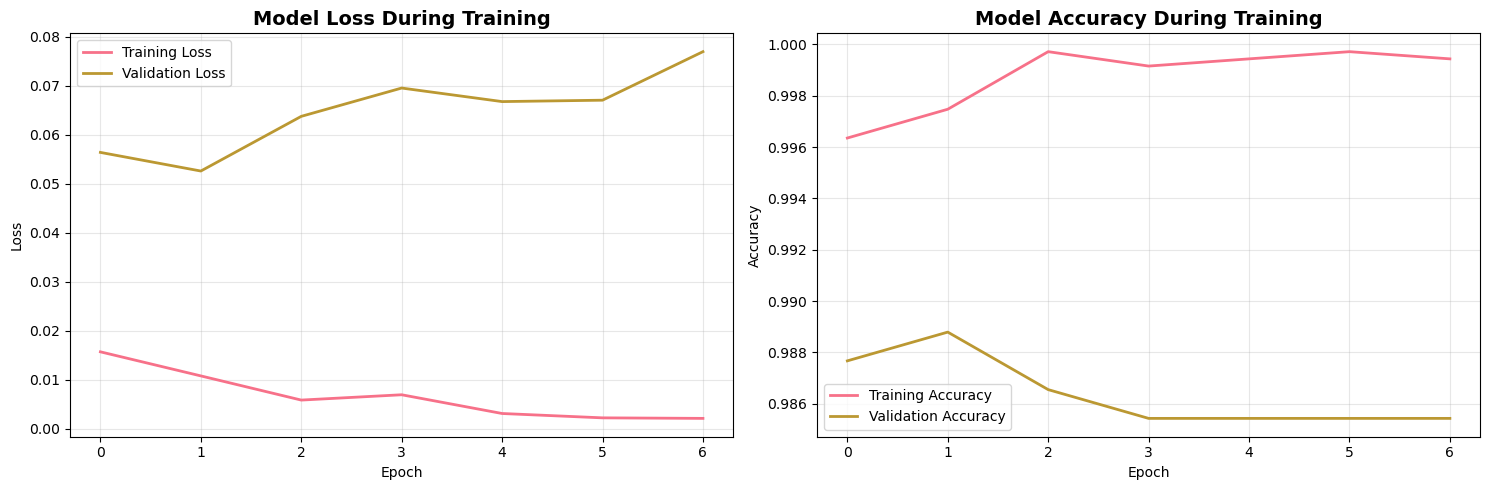

In [7]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Make predictions
Ypred_proba = model.predict(X_test)
Ypred = (Ypred_proba > 0.5).astype("int32").flatten()

# Calculate metrics
accuracy = metrics.accuracy_score(Ytest, Ypred)
precision = metrics.precision_score(Ytest, Ypred)
recall = metrics.recall_score(Ytest, Ypred)
f1 = metrics.f1_score(Ytest, Ypred)
conf_matrix = metrics.confusion_matrix(Ytest, Ypred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(metrics.classification_report(Ytest, Ypred, target_names=['Ham', 'Spam']))


MODEL EVALUATION
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step  
Accuracy:  0.9848
Precision: 0.9583
Recall:    0.9262
F1-Score:  0.9420

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.96      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



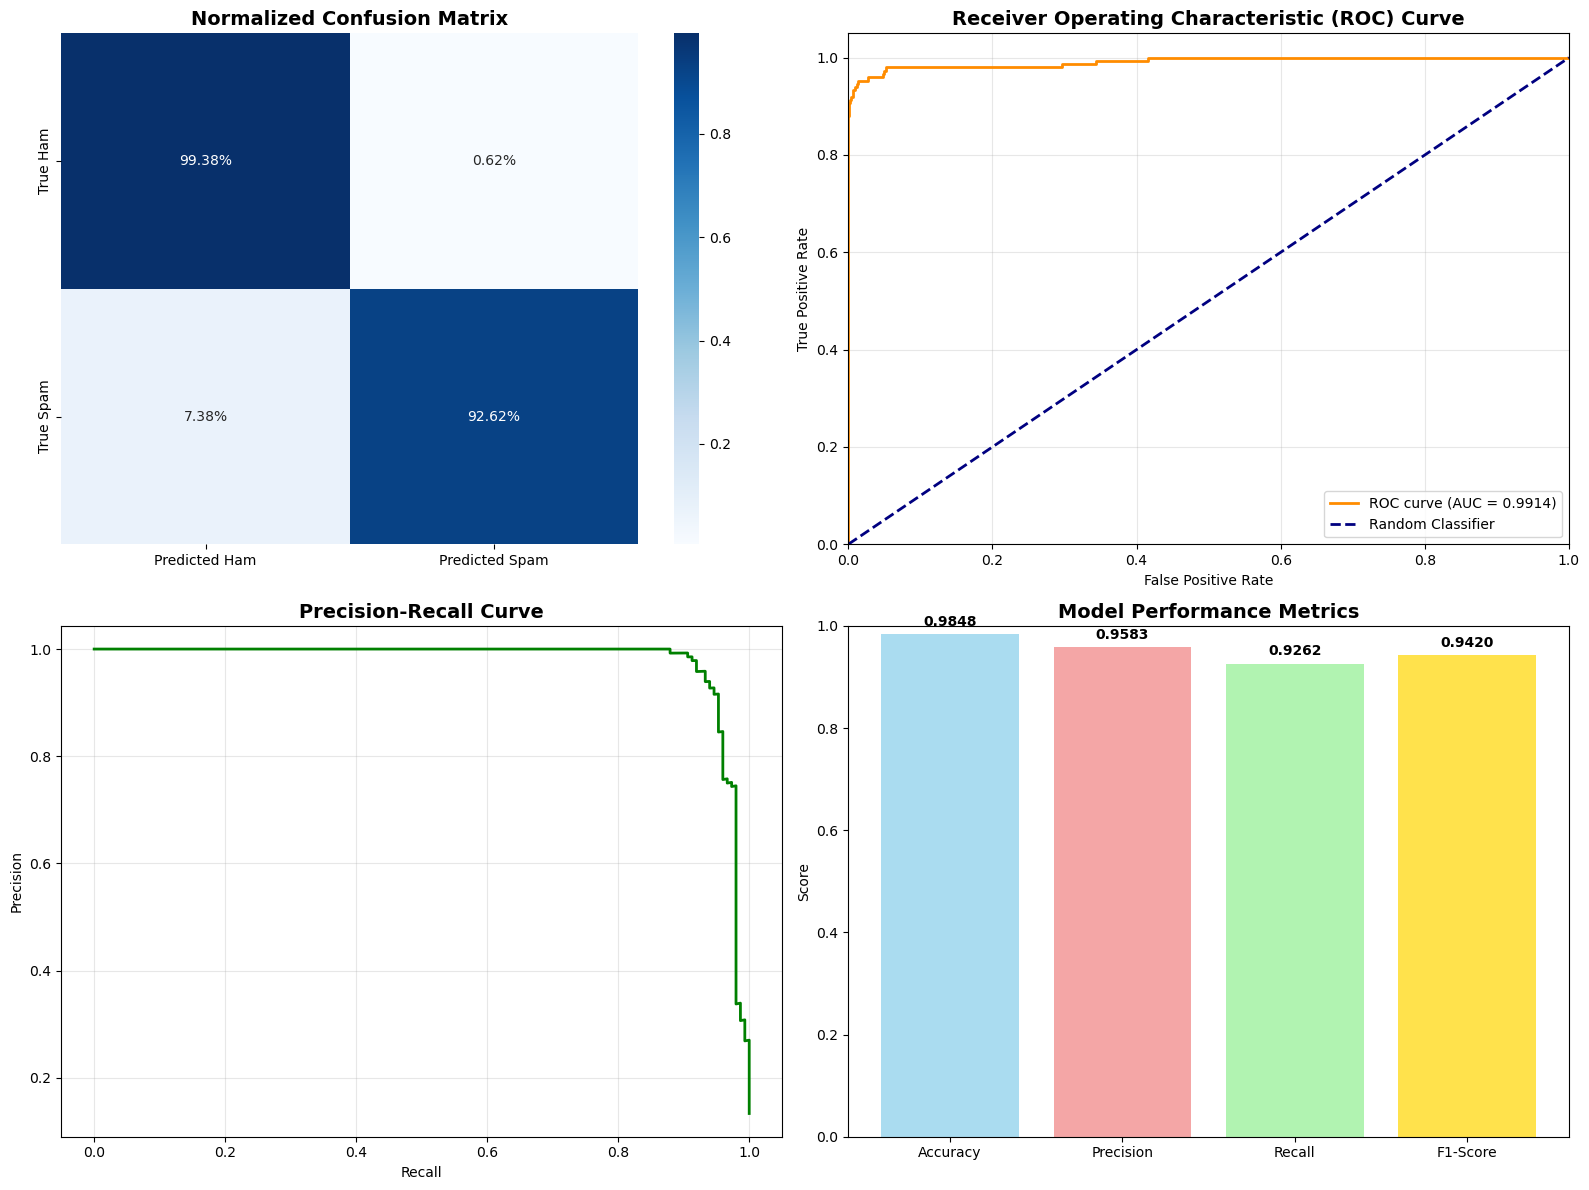

In [9]:
# Create comprehensive evaluation visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 7.1 Fixed Confusion Matrix (using sns instead of sn)
cm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', 
           xticklabels=['Predicted Ham', 'Predicted Spam'],
           yticklabels=['True Ham', 'True Spam'], ax=axes[0,0])
axes[0,0].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')

# 7.2 ROC Curve
fpr, tpr, thresholds = metrics.roc_curve(Ytest, Ypred_proba)
roc_auc = metrics.auc(fpr, tpr)

axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 7.3 Precision-Recall Curve
precision_curve, recall_curve, _ = metrics.precision_recall_curve(Ytest, Ypred_proba)
axes[1,0].plot(recall_curve, precision_curve, color='green', lw=2)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# 7.4 Metrics Comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

bars = axes[1,1].bar(metrics_names, metrics_values, color=colors, alpha=0.7)
axes[1,1].set_ylim(0, 1)
axes[1,1].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Score')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                  f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Test the model with custom examples
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

def predict_message(message, model, tokenizer, max_length):
    """Predict if a message is spam or ham"""
    # Preprocess the message
    sequence = tokenizer.texts_to_sequences([message])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
    
    # Make prediction
    prediction = model.predict(padded_sequence, verbose=0)[0][0]
    label = "SPAM" if prediction > 0.5 else "HAM"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    
    return label, confidence, prediction

# Sample messages for testing
test_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Text YES to claim your prize!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your bank account has been suspended. Click here to verify: http://bit.ly/secure-bank",
    "Can you pick up some milk on your way home?",
    "FREE entry into our £500 weekly cash prize! Reply WIN to enter. T&C apply."
]

# Test each message
for i, message in enumerate(test_messages, 1):
    label, confidence, raw_score = predict_message(message, model, tokenizer, MAX_SEQUENCE_LENGTH)
    print(f"\nMessage {i}:")
    print(f"Text: {message}")
    print(f"Prediction: {label} (Confidence: {confidence:.4f}, Raw Score: {raw_score:.4f})")


SAMPLE PREDICTIONS

Message 1:
Text: Congratulations! You've won a $1000 Walmart gift card. Text YES to claim your prize!
Prediction: SPAM (Confidence: 0.9969, Raw Score: 0.9969)

Message 2:
Text: Hey, are we still meeting for lunch tomorrow?
Prediction: HAM (Confidence: 0.9999, Raw Score: 0.0001)

Message 3:
Text: URGENT: Your bank account has been suspended. Click here to verify: http://bit.ly/secure-bank
Prediction: SPAM (Confidence: 0.9985, Raw Score: 0.9985)

Message 4:
Text: Can you pick up some milk on your way home?
Prediction: HAM (Confidence: 0.9999, Raw Score: 0.0001)

Message 5:
Text: FREE entry into our £500 weekly cash prize! Reply WIN to enter. T&C apply.
Prediction: SPAM (Confidence: 0.9994, Raw Score: 0.9994)


In [11]:
# Analyze important words for classification
print("\n" + "="*50)
print("WORD FREQUENCY ANALYSIS")
print("="*50)

# Get most frequent words in spam and ham messages
spam_words = []
for message in df[df['label'] == 'spam']['message']:
    spam_words.extend(message.lower().split())

ham_words = []
for message in df[df['label'] == 'ham']['message']:
    ham_words.extend(message.lower().split())

# Count word frequencies
spam_word_freq = Counter(spam_words)
ham_word_freq = Counter(ham_words)

# Get top 15 spam words (excluding common words)
common_english_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'his', 'our', 'their'}
top_spam_words = [(word, count) for word, count in spam_word_freq.most_common(50) if word not in common_english_words and len(word) > 2][:15]
top_ham_words = [(word, count) for word, count in ham_word_freq.most_common(50) if word not in common_english_words and len(word) > 2][:15]

print("\nTop 15 characteristic words in SPAM messages:")
for word, count in top_spam_words:
    print(f"  {word}: {count}")

print("\nTop 15 characteristic words in HAM messages:")
for word, count in top_ham_words:
    print(f"  {word}: {count}")

print("\n🎉 Project completed successfully!")


WORD FREQUENCY ANALYSIS

Top 15 characteristic words in SPAM messages:
  call: 342
  free: 180
  txt: 136
  from: 127
  text: 112
  mobile: 109
  claim: 106
  reply: 101
  now: 93
  stop: 89
  this: 86
  get: 82
  just: 77
  now!: 70
  new: 69

Top 15 characteristic words in HAM messages:
  that: 442
  not: 381
  i'm: 369
  can: 356
  get: 293
  just: 286
  &lt;#&gt;: 276
  when: 270
  how: 245
  what: 235
  all: 231
  got: 227
  this: 226
  like: 221
  call: 215

🎉 Project completed successfully!
